cpu


100%|██████████| 170M/170M [00:03<00:00, 45.5MB/s]


Epoch [1/5], Loss: 0.0526
Epoch [2/5], Loss: 0.0419
Epoch [3/5], Loss: 0.0326
Epoch [4/5], Loss: 0.0346
Epoch [5/5], Loss: 0.0312


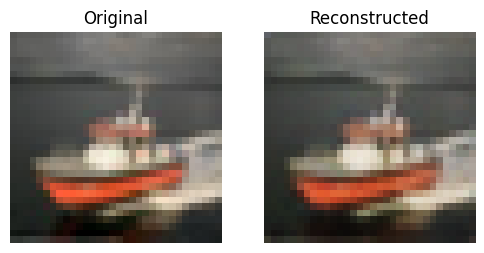

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=True)

class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 16 -> 8
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),   # 16 -> 32
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = EncoderDecoder().to(device)

criterion = nn.L1Loss()  # or nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

epochs = 5

for epoch in range(epochs):
    for images, _ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

import numpy as np

def show_images(real, fake):
    real = real.cpu().detach().numpy()
    fake = fake.cpu().detach().numpy()

    real = np.transpose(real[0], (1,2,0))
    fake = np.transpose(fake[0], (1,2,0))

    real = (real + 1) / 2
    fake = (fake + 1) / 2

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(real)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(fake)
    plt.axis("off")

    plt.show()

model.eval()
with torch.no_grad():
    sample, _ = next(iter(train_loader))
    sample = sample.to(device)
    output = model(sample)

show_images(sample, output)